# Data Mining_2_Module_3
## 03 — Time-Series Clustering

We used **two clustering algorithms** with Euclidean geometry:

1. K-Means;
2. Agglomerative Hierarchical Clustering with Ward linkage.

Both are evaluated under two signal configurations:

- **with light:** `X, Y, Z, enmo, light`;
- **without light:** `X, Y, Z, enmo`.

The globally standardized dataset from notebook 01 is used because this is an unsupervised task.

Before clustering, each 200-point multivariate series is compressed with **PAA from 200 to 50 time steps**.

In [1]:
from pathlib import Path
import warnings, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42

PROJECT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2"),
    Path("/Users/sarabiiavasco/Codice/DATA MINING/Progetto DM2"),
    Path("/Users/sarabiiavasco/Codice/DATA MINING/progetto dm2"),
]

def is_project_dir(path):
    return path.exists() and (
        (path / "data").exists()
        or (path / "artifacts").exists()
        or any(path.glob("CMI_timeseries_dataset*.pkl"))
    )

PROJECT_DIR = next((p for p in PROJECT_CANDIDATES if is_project_dir(p)), None)
if PROJECT_DIR is None:
    raise FileNotFoundError(
        "Project folder not found. Update PROJECT_CANDIDATES with your local project path."
    )

TS_PROCESSED_DIR = PROJECT_DIR / "data" / "processed" / "timeseries"
MODULE3_DIR = PROJECT_DIR / "artifacts" / "module3"

TS_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODULE3_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Processed time-series directory:", TS_PROCESSED_DIR)
print("Module 3 artifacts:", MODULE3_DIR)

Project directory: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2
Processed time-series directory: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/data/processed/timeseries
Module 3 artifacts: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/artifacts/module3


In [2]:
INPUT_PATH = TS_PROCESSED_DIR / "CMI_timeseries_dataset_preproc_scal.pkl"
if not INPUT_PATH.exists():
    raise FileNotFoundError("Run notebook 01 first: " + str(INPUT_PATH))

ts_scaled = pd.read_pickle(INPUT_PATH)
CLUSTER_DIR = MODULE3_DIR / "clustering"
CLUSTER_DIR.mkdir(parents=True, exist_ok=True)

print("Loaded:", INPUT_PATH)
print("Time series:", len(ts_scaled))

Loaded: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/data/processed/timeseries/CMI_timeseries_dataset_preproc_scal.pkl
Time series: 4258


## 1. Shared clustering utilities

In [3]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import linkage, dendrogram

def paa_multivariate(X, n_segments=50):
    n_samples, n_steps, n_channels = X.shape
    if n_steps % n_segments != 0:
        raise ValueError("n_steps must be divisible by n_segments.")
    seg_len = n_steps // n_segments
    return X.reshape(n_samples, n_segments, seg_len, n_channels).mean(axis=2)

def make_agglomerative(k):
    try:
        return AgglomerativeClustering(n_clusters=k, linkage="ward", metric="euclidean")
    except TypeError:
        return AgglomerativeClustering(n_clusters=k, linkage="ward")

def build_array(signal_cols):
    X = np.stack([ts[signal_cols].to_numpy(dtype=float) for ts in ts_scaled])
    ids = np.array([ts["id"].iloc[0] for ts in ts_scaled])
    y = np.array([int(ts["sii_binary"].iloc[0]) for ts in ts_scaled])
    if not np.isfinite(X).all():
        raise ValueError("Non-finite values found in clustering input.")
    return X, ids, y

def evaluate_k_values(F, k_values=range(2,11)):
    km_rows, h_rows = [], []
    for k in k_values:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
        km_labels = km.fit_predict(F)
        km_rows.append({
            "k":k, "sse":km.inertia_,
            "silhouette":silhouette_score(
                F, km_labels, sample_size=min(1500,len(F)), random_state=RANDOM_STATE
            )
        })

        h = make_agglomerative(k)
        h_labels = h.fit_predict(F)
        h_rows.append({
            "k":k,
            "silhouette":silhouette_score(
                F, h_labels, sample_size=min(1500,len(F)), random_state=RANDOM_STATE
            )
        })
    return pd.DataFrame(km_rows), pd.DataFrame(h_rows)

def plot_selection(km_df, h_df, title):
    fig, axes = plt.subplots(1,3,figsize=(16,4))
    axes[0].plot(km_df["k"],km_df["sse"],marker="o")
    axes[0].set_title(title+" — KMeans SSE")
    axes[1].plot(km_df["k"],km_df["silhouette"],marker="o")
    axes[1].set_title(title+" — KMeans silhouette")
    axes[2].plot(h_df["k"],h_df["silhouette"],marker="o")
    axes[2].set_title(title+" — Hierarchical silhouette")
    for ax in axes:
        ax.set_xlabel("k"); ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()

def compute_embeddings(F):
    pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
    pca_xy = pca2.fit_transform(F)

    n_pre = min(30, F.shape[1], F.shape[0]-1)
    F_pre = PCA(n_components=n_pre, random_state=RANDOM_STATE).fit_transform(F)

    tsne = TSNE(
        n_components=2, perplexity=30, init="pca",
        learning_rate="auto", random_state=RANDOM_STATE
    )
    tsne_xy = tsne.fit_transform(F_pre)
    return pca_xy, tsne_xy, pca2.explained_variance_ratio_

def plot_embedding(points, labels, title):
    plt.figure(figsize=(7,5))
    sc = plt.scatter(points[:,0],points[:,1],c=labels,s=18,alpha=.7)
    plt.title(title); plt.xlabel("Dimension 1"); plt.ylabel("Dimension 2")
    plt.colorbar(sc,label="cluster"); plt.grid(alpha=.2); plt.tight_layout(); plt.show()

def target_table(labels, y, name):
    table = pd.crosstab(
        pd.Series(labels,name="cluster"),
        pd.Series(y,name="sii_binary")
    )
    print(name)
    display(table)
    display(pd.crosstab(
        pd.Series(labels,name="cluster"),
        pd.Series(y,name="sii_binary"),
        normalize="index"
    ).round(3))
    return table

def plot_mean_profiles(X, labels, cols, title):
    labels = np.asarray(labels)
    for ci,col in enumerate(cols):
        plt.figure(figsize=(12,3.5))
        for cluster in sorted(np.unique(labels)):
            curves = X[labels==cluster,:,ci]
            mean = curves.mean(axis=0)
            std = curves.std(axis=0)
            t = np.arange(X.shape[1])
            plt.plot(t,mean,label=f"cluster {cluster} (n={len(curves)})")
            plt.fill_between(t,mean-std,mean+std,alpha=.12)
        plt.title(f"{title} — mean ± std — {col}")
        plt.xlabel("Time step"); plt.ylabel("scaled value")
        plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

# With light

Final choices from the corrected pipeline:
- K-Means: **k=4**;
- Hierarchical Ward: **k=4**.

X: (4258, 200, 5) PAA: (4258, 50, 5) Flattened: (4258, 250)


,k,sse,silhouette
0,2,673457.957876,0.144612
1,3,644412.402615,0.121280
2,4,618432.098325,0.127792
3,5,606849.047847,0.125948
4,6,599131.217524,0.051730
5,7,593071.484718,0.055556
6,8,587803.680775,0.036343
7,9,582303.281108,0.037289
8,10,577480.336500,0.031382


,k,silhouette
0,2,0.119882
1,3,0.098567
2,4,0.113987
3,5,0.118659
4,6,0.096630
5,7,0.093731
6,8,0.094723
7,9,0.076761
8,10,0.013898


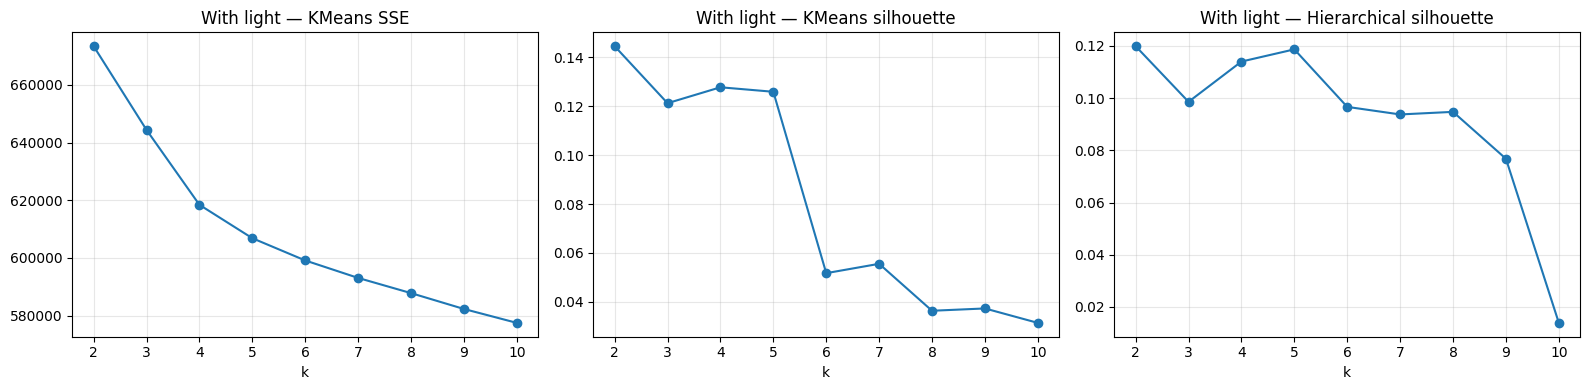

In [4]:
cols_with_light = ["X","Y","Z","enmo","light"]
X_with, ids_with, y_with = build_array(cols_with_light)
X_with_paa = paa_multivariate(X_with, 50)
F_with = X_with_paa.reshape(len(X_with_paa), -1)

print("X:",X_with.shape,"PAA:",X_with_paa.shape,"Flattened:",F_with.shape)

km_with_grid, h_with_grid = evaluate_k_values(F_with)
display(km_with_grid)
display(h_with_grid)
plot_selection(km_with_grid,h_with_grid,"With light")

In [5]:
km_with = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=20)
labels_km_with = km_with.fit_predict(F_with)

h_with = make_agglomerative(4)
labels_h_with = h_with.fit_predict(F_with)

print("KMeans sizes:")
display(pd.Series(labels_km_with).value_counts().sort_index().to_frame("n"))
print("Hierarchical sizes:")
display(pd.Series(labels_h_with).value_counts().sort_index().to_frame("n"))

KMeans sizes:


,n
0,240
1,2150
2,1241
3,627


Hierarchical sizes:


,n
0,253
1,2212
2,558
3,1235


## Dimensionality reduction — PCA and t-SNE

PCA explained variance: [0.15057511 0.06786429] total: 0.21843940459379246


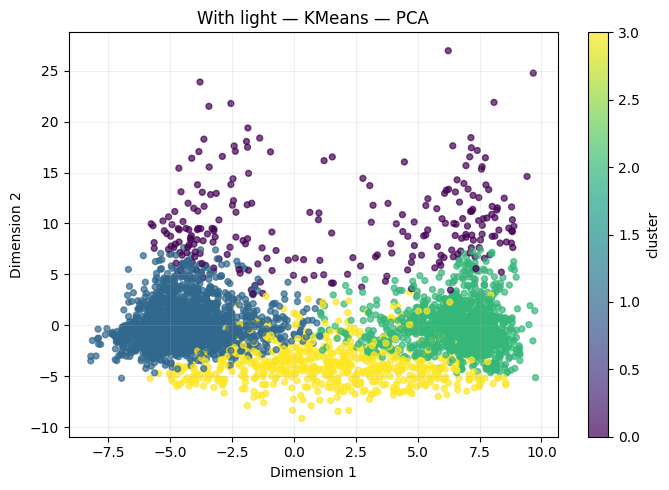

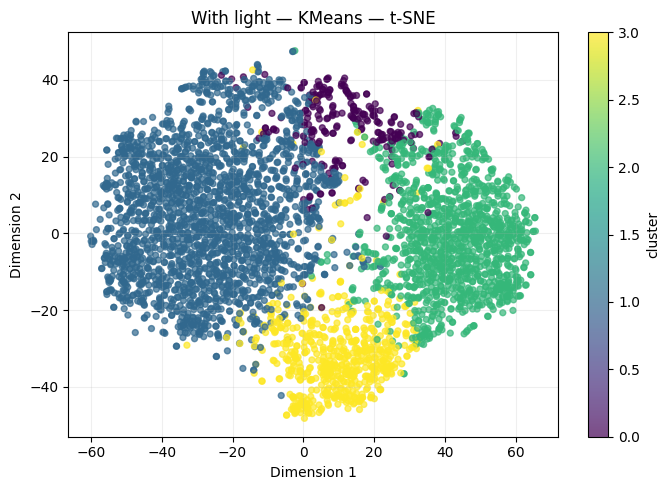

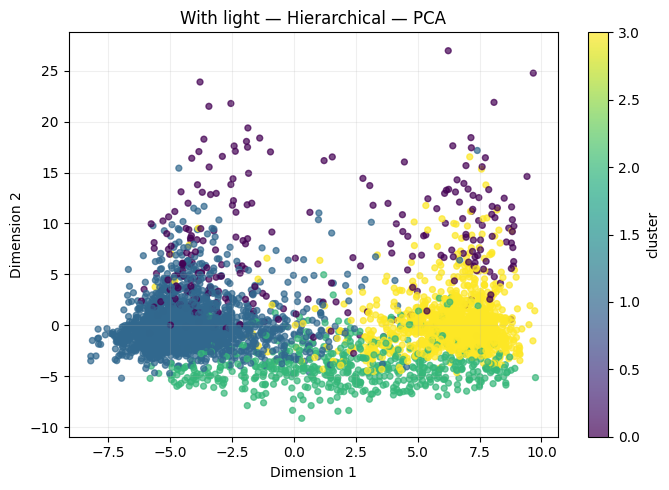

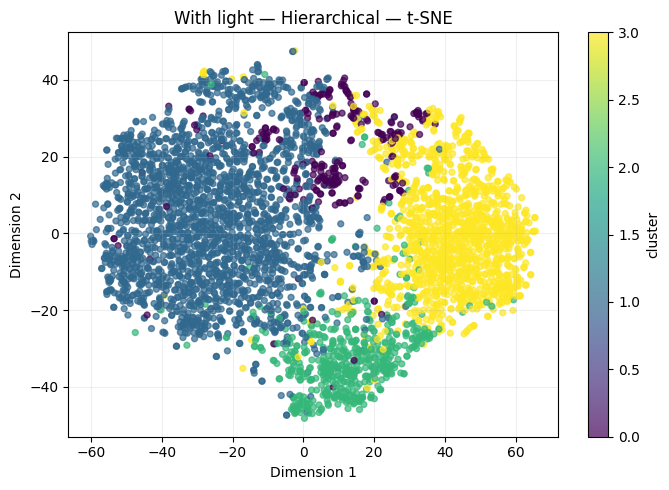

In [6]:
pca_with, tsne_with, pca_var_with = compute_embeddings(F_with)
print("PCA explained variance:",pca_var_with,"total:",pca_var_with.sum())

plot_embedding(pca_with,labels_km_with,"With light — KMeans — PCA")
plot_embedding(tsne_with,labels_km_with,"With light — KMeans — t-SNE")
plot_embedding(pca_with,labels_h_with,"With light — Hierarchical — PCA")
plot_embedding(tsne_with,labels_h_with,"With light — Hierarchical — t-SNE")

## Target distribution and temporal cluster profiles

With light — KMeans


sii_binary,0,1
cluster,,
0,168,72
1,1401,749
2,890,351
3,396,231


sii_binary,0,1
cluster,,
0,0.700,0.300
1,0.652,0.348
2,0.717,0.283
3,0.632,0.368


With light — Hierarchical


sii_binary,0,1
cluster,,
0,186,67
1,1442,770
2,333,225
3,894,341


sii_binary,0,1
cluster,,
0,0.735,0.265
1,0.652,0.348
2,0.597,0.403
3,0.724,0.276


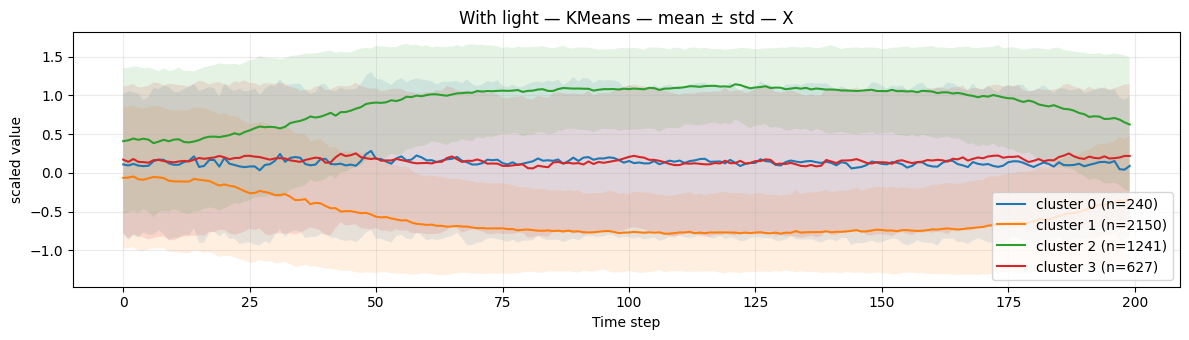

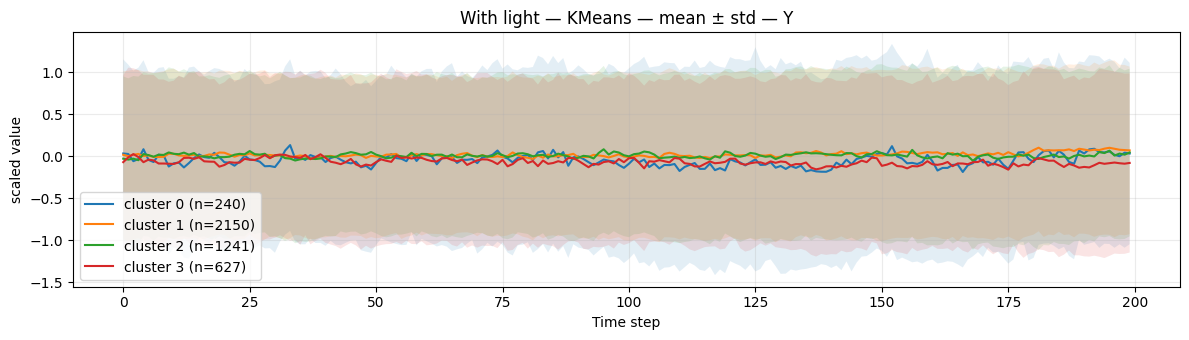

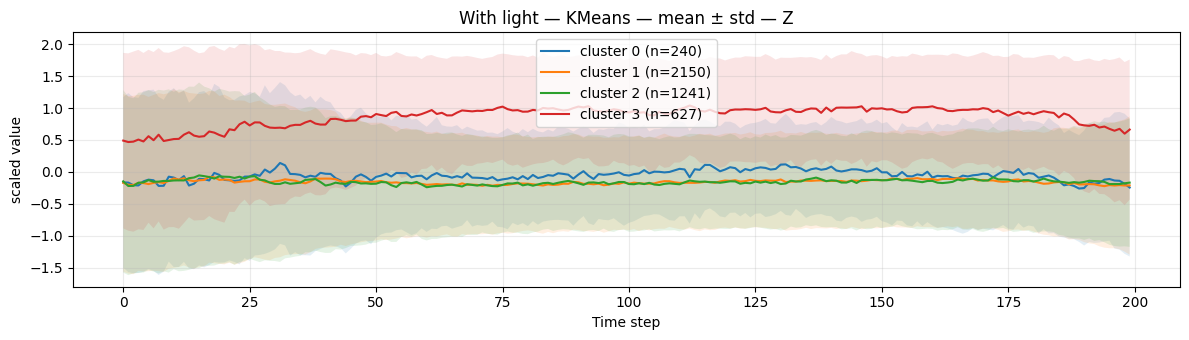

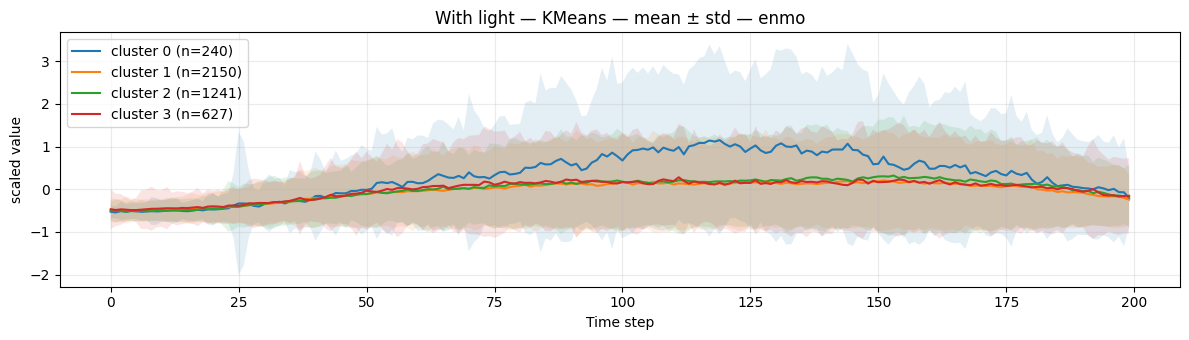

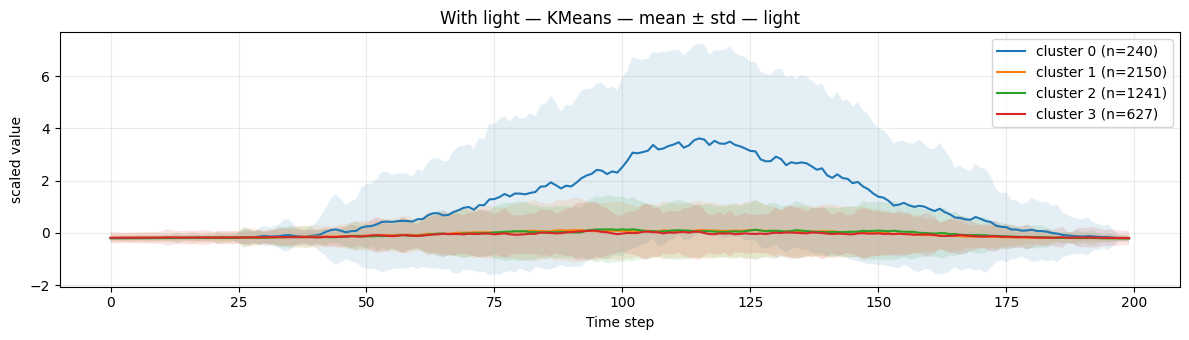

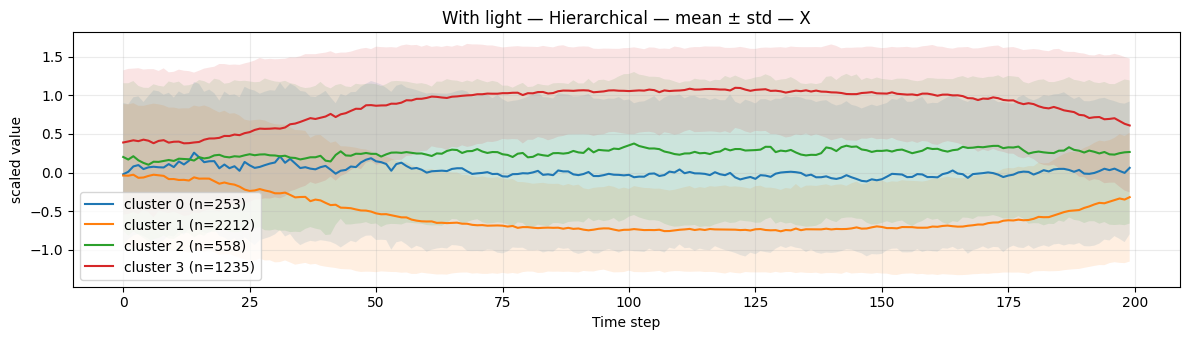

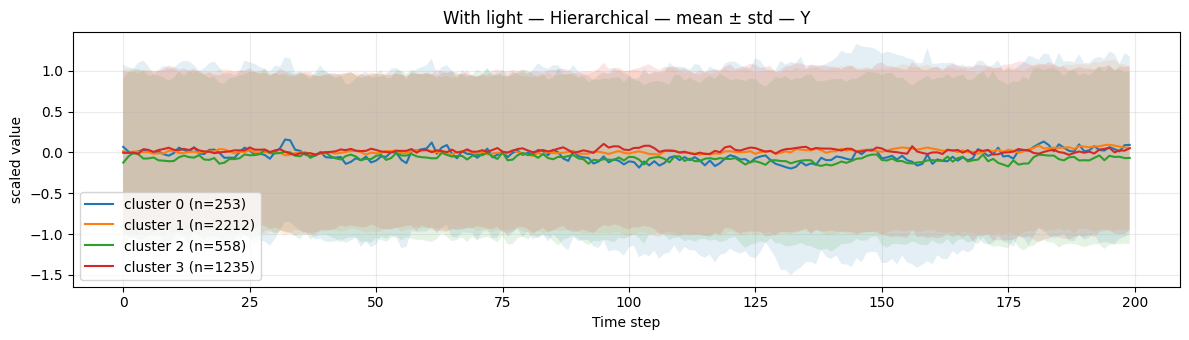

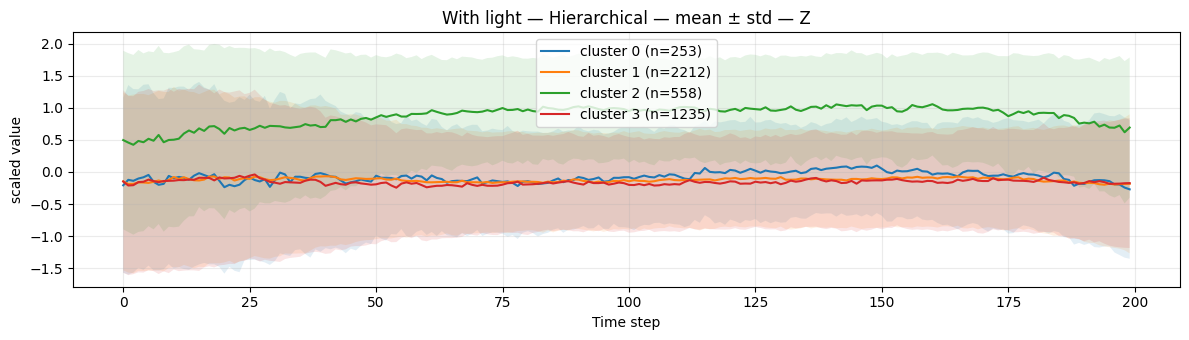

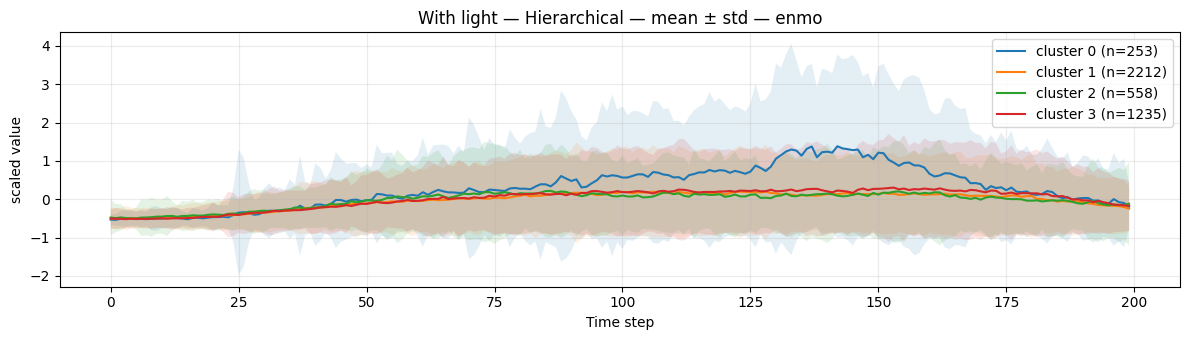

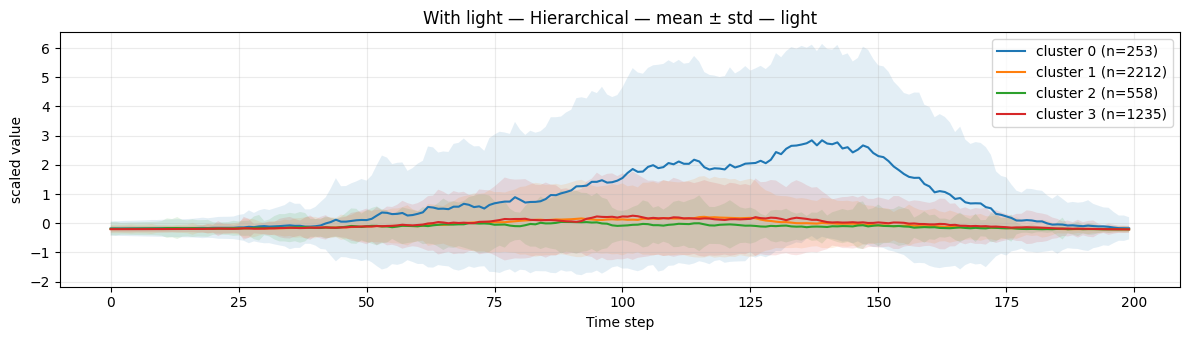

In [7]:
target_table(labels_km_with,y_with,"With light — KMeans")
target_table(labels_h_with,y_with,"With light — Hierarchical")
plot_mean_profiles(X_with,labels_km_with,cols_with_light,"With light — KMeans")
plot_mean_profiles(X_with,labels_h_with,cols_with_light,"With light — Hierarchical")

# Without light

Final choices:
- K-Means: **k=3**;
- Hierarchical Ward: **k=3**.


,k,sse,silhouette
0,2,504985.714685,0.170151
1,3,476412.578150,0.160574
2,4,468127.023847,0.070122
3,5,462211.613484,0.057821
4,6,456557.997609,0.052407
5,7,451442.621661,0.044913
6,8,447596.229185,0.019583
7,9,443897.111019,0.014769
8,10,441113.222934,0.011744


,k,silhouette
0,2,0.155883
1,3,0.154781
2,4,0.156229
3,5,0.070636
4,6,0.046063
5,7,0.009075
6,8,0.010943
7,9,0.007137
8,10,0.008780


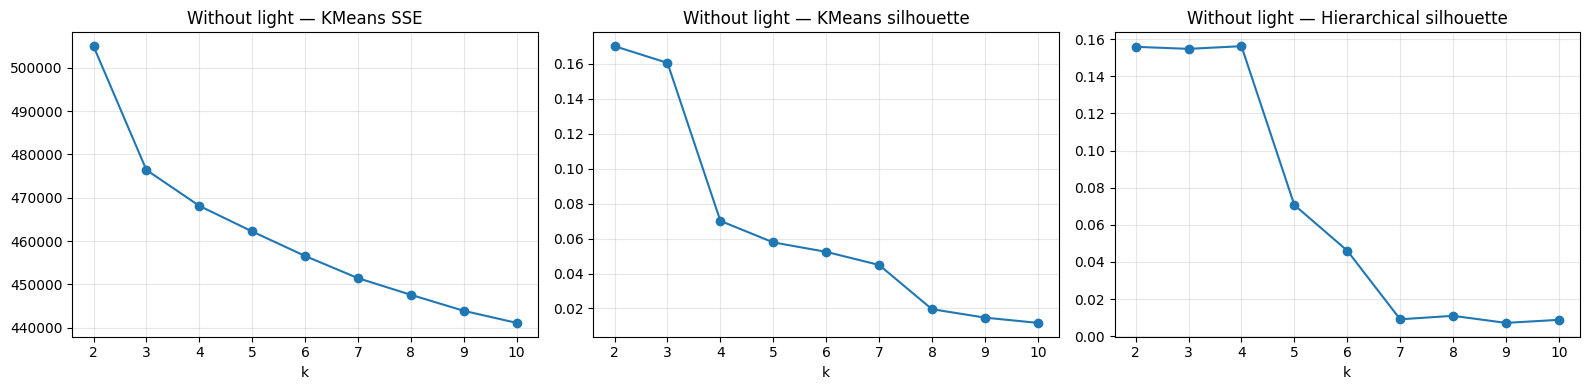

In [8]:
cols_without_light = ["X","Y","Z","enmo"]
X_without, ids_without, y_without = build_array(cols_without_light)
X_without_paa = paa_multivariate(X_without, 50)
F_without = X_without_paa.reshape(len(X_without_paa), -1)

km_without_grid, h_without_grid = evaluate_k_values(F_without)
display(km_without_grid)
display(h_without_grid)
plot_selection(km_without_grid,h_without_grid,"Without light")

In [9]:
km_without = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=20)
labels_km_without = km_without.fit_predict(F_without)

h_without = make_agglomerative(3)
labels_h_without = h_without.fit_predict(F_without)

print("KMeans sizes:")
display(pd.Series(labels_km_without).value_counts().sort_index().to_frame("n"))
print("Hierarchical sizes:")
display(pd.Series(labels_h_without).value_counts().sort_index().to_frame("n"))

KMeans sizes:


,n
0,652
1,1349
2,2257


Hierarchical sizes:


,n
0,1451
1,2321
2,486


PCA explained variance: [0.19196314 0.08091425] total: 0.2728773849578188


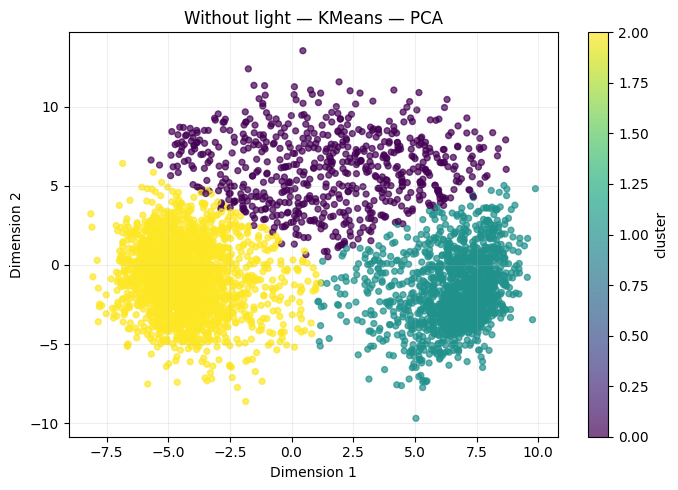

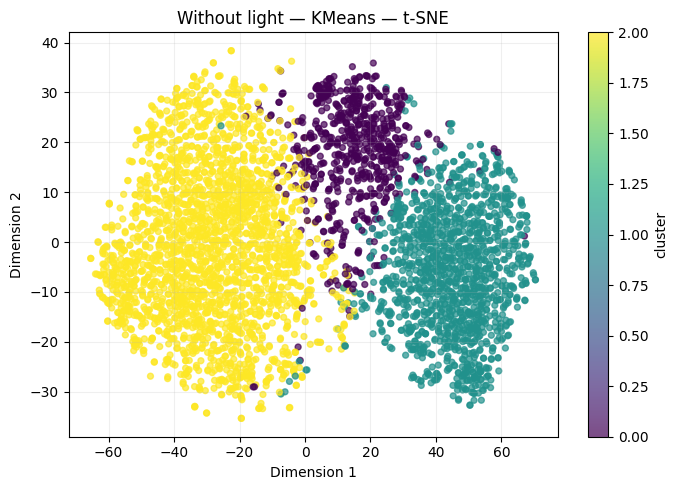

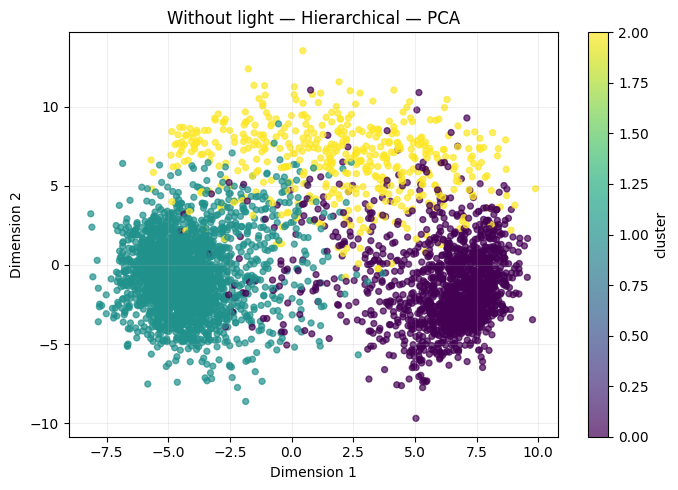

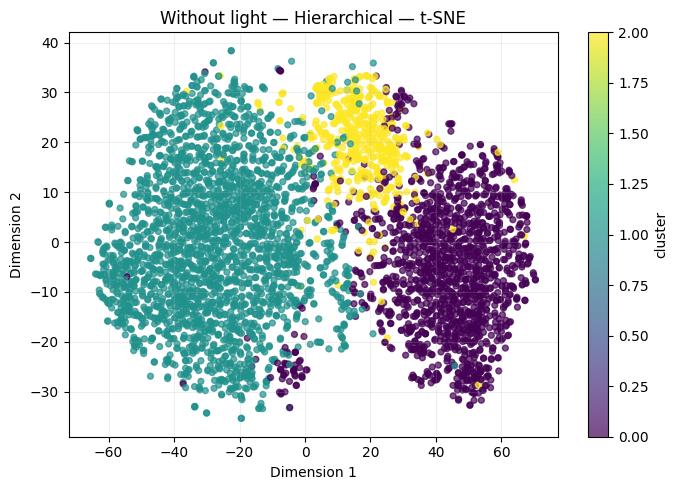

Without light — KMeans


sii_binary,0,1
cluster,,
0,412,240
1,971,378
2,1472,785


sii_binary,0,1
cluster,,
0,0.632,0.368
1,0.720,0.280
2,0.652,0.348


Without light — Hierarchical


sii_binary,0,1
cluster,,
0,1054,397
1,1510,811
2,291,195


sii_binary,0,1
cluster,,
0,0.726,0.274
1,0.651,0.349
2,0.599,0.401


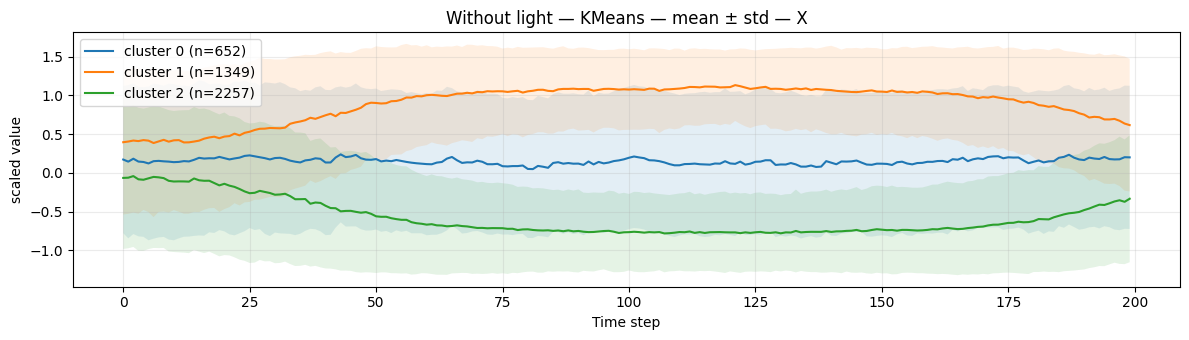

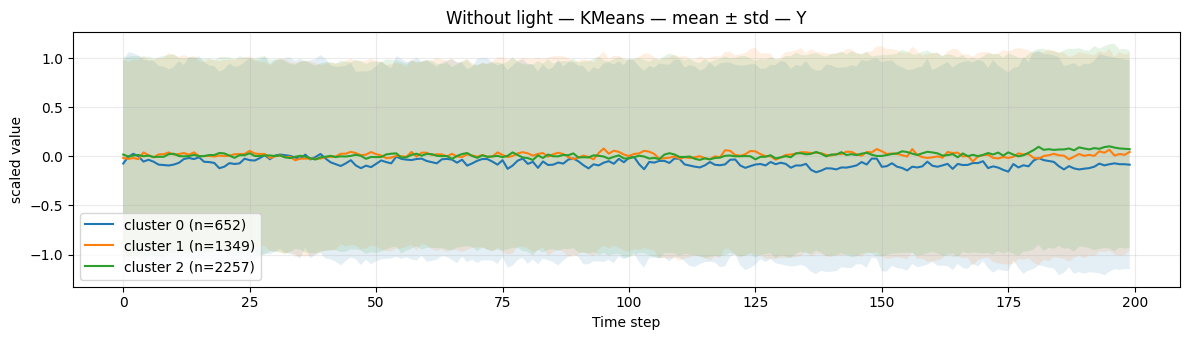

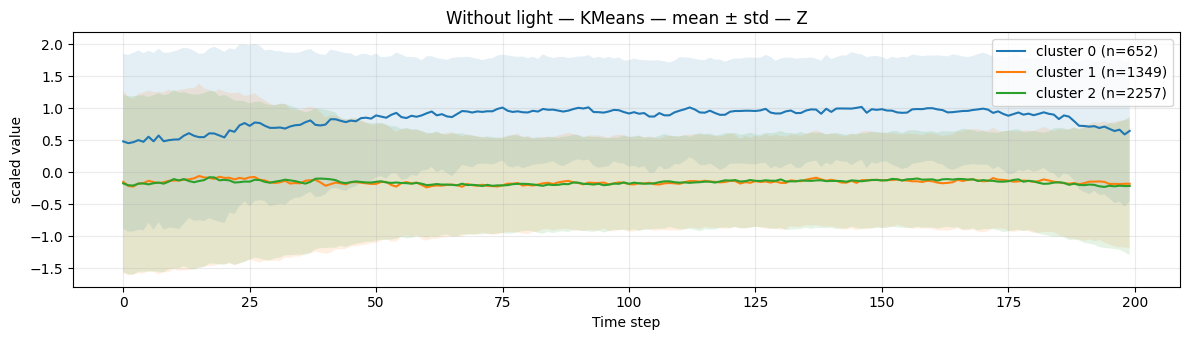

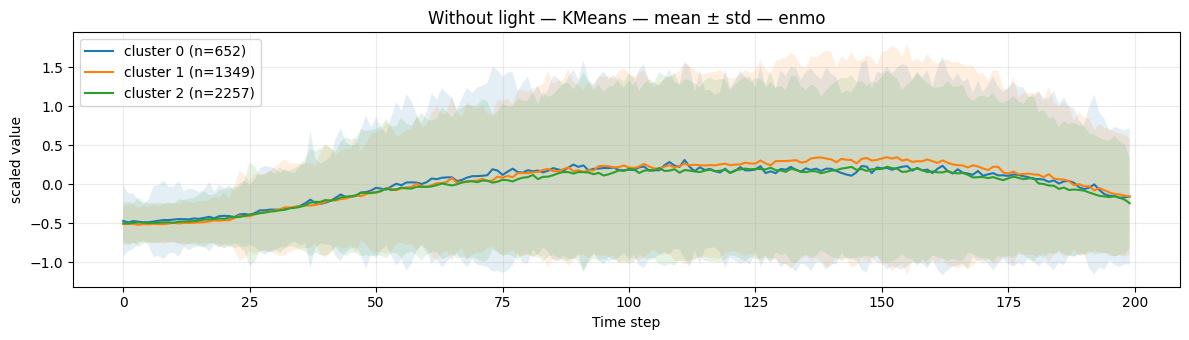

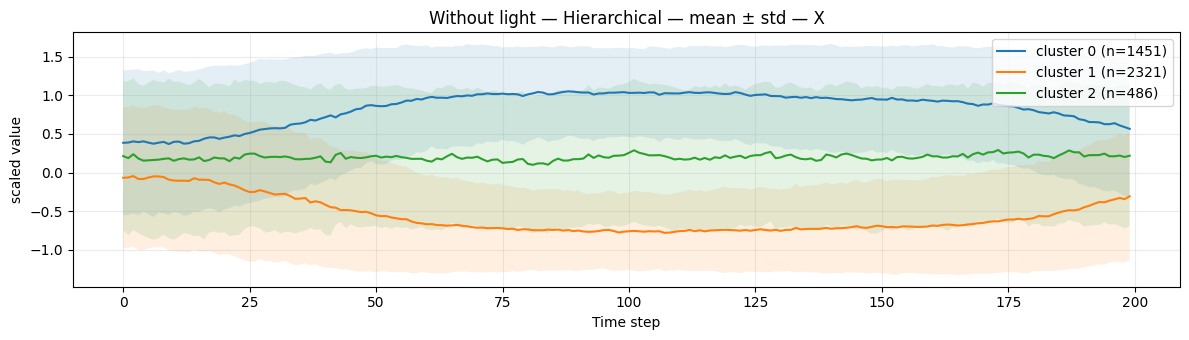

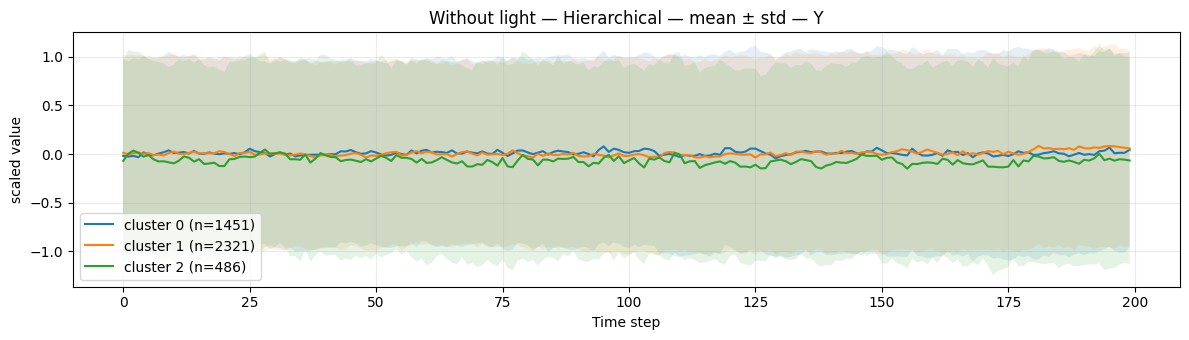

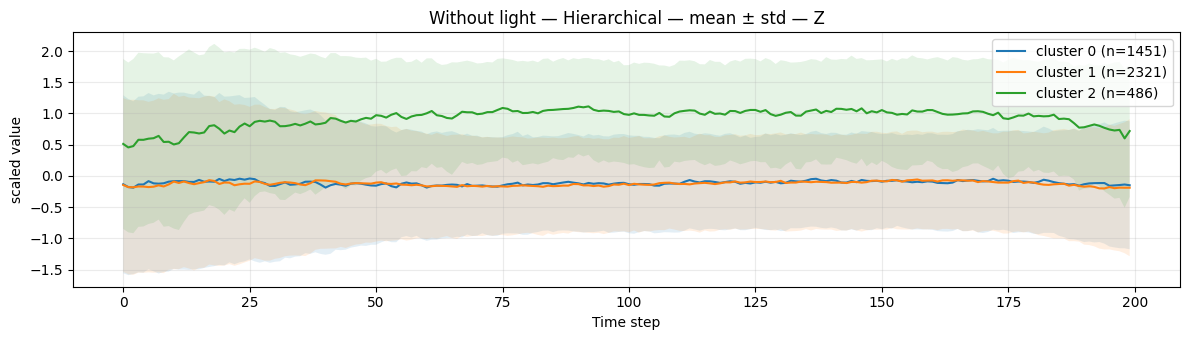

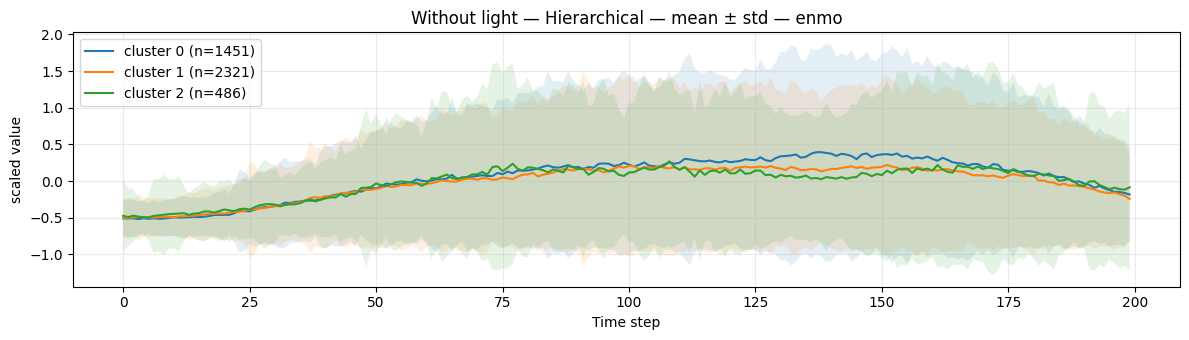

In [10]:
pca_without, tsne_without, pca_var_without = compute_embeddings(F_without)
print("PCA explained variance:",pca_var_without,"total:",pca_var_without.sum())

plot_embedding(pca_without,labels_km_without,"Without light — KMeans — PCA")
plot_embedding(tsne_without,labels_km_without,"Without light — KMeans — t-SNE")
plot_embedding(pca_without,labels_h_without,"Without light — Hierarchical — PCA")
plot_embedding(tsne_without,labels_h_without,"Without light — Hierarchical — t-SNE")

target_table(labels_km_without,y_without,"Without light — KMeans")
target_table(labels_h_without,y_without,"Without light — Hierarchical")

plot_mean_profiles(X_without,labels_km_without,cols_without_light,"Without light — KMeans")
plot_mean_profiles(X_without,labels_h_without,cols_without_light,"Without light — Hierarchical")

## 5. Save clustering artifacts

In [11]:
embedding_with = pd.DataFrame({
    "ts_index":np.arange(len(ids_with)), "id":ids_with, "sii_binary":y_with,
    "PC1":pca_with[:,0],"PC2":pca_with[:,1],
    "TSNE1":tsne_with[:,0],"TSNE2":tsne_with[:,1],
    "kmeans_cluster":labels_km_with,
    "hierarchical_cluster":labels_h_with,
})
embedding_without = pd.DataFrame({
    "ts_index":np.arange(len(ids_without)), "id":ids_without, "sii_binary":y_without,
    "PC1":pca_without[:,0],"PC2":pca_without[:,1],
    "TSNE1":tsne_without[:,0],"TSNE2":tsne_without[:,1],
    "kmeans_cluster":labels_km_without,
    "hierarchical_cluster":labels_h_without,
})

embedding_with.to_csv(CLUSTER_DIR/"embedding_with_light.csv",index=False)
embedding_without.to_csv(CLUSTER_DIR/"embedding_without_light.csv",index=False)
km_with_grid.to_csv(CLUSTER_DIR/"kmeans_grid_with_light.csv",index=False)
h_with_grid.to_csv(CLUSTER_DIR/"hierarchical_grid_with_light.csv",index=False)
km_without_grid.to_csv(CLUSTER_DIR/"kmeans_grid_without_light.csv",index=False)
h_without_grid.to_csv(CLUSTER_DIR/"hierarchical_grid_without_light.csv",index=False)

print("Clustering artifacts saved in:",CLUSTER_DIR)

Clustering artifacts saved in: /Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2/artifacts/module3/clustering
